# Regression for IoT — Temperature Prediction


[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/BlackBox2C/blob/main/notebooks/03_regression_temperature.ipynb)
[![View on GitHub](https://img.shields.io/badge/View-GitHub-black?logo=github)](https://github.com/AxelSkrauba/BlackBox2C/blob/main/notebooks/03_regression_temperature.ipynb)

This notebook demonstrates regression use cases for embedded systems:
- DecisionTree and RandomForest regressors → C code
- Fixed-point arithmetic for microcontrollers without FPU
- Trade-off analysis: MAE vs. code size vs. depth

In [1]:
# !pip install blackbox2c -q  # Uncomment on Colab

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

from blackbox2c import convert, Converter, ConversionConfig

# Reproducible synthetic dataset: temperature from time-of-day, humidity, pressure
np.random.seed(42)
N = 600
hour     = np.random.uniform(0, 24, N)
humidity = np.random.uniform(30, 90, N)
pressure = np.random.uniform(980, 1040, N)

temperature = (
    15 + 10 * np.sin((hour - 6) * np.pi / 12)
    - 0.05 * (humidity - 60)
    + 0.10 * (pressure - 1010)
    + np.random.normal(0, 2, N)
)

X = np.column_stack([hour, humidity, pressure])
y = temperature
feature_names = ["hour", "humidity", "pressure"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")
print(f"Target range: {y.min():.1f} – {y.max():.1f} °C")

Train: 420  |  Test: 180
Target range: -1.6 – 31.6 °C


## 1. Train regressors

In [3]:
regressors = {
    "DecisionTree (d=4)": DecisionTreeRegressor(max_depth=4, random_state=42),
    "DecisionTree (d=6)": DecisionTreeRegressor(max_depth=6, random_state=42),
    "RandomForest":       RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    "GradientBoosting":   GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=42),
}

for name, m in regressors.items():
    m.fit(X_train, y_train)
    mae = mean_absolute_error(y_test, m.predict(X_test))
    r2  = r2_score(y_test, m.predict(X_test))
    print(f"{name:<25}  MAE={mae:.3f}°C  R²={r2:.4f}")

DecisionTree (d=4)         MAE=2.346°C  R²=0.8648
DecisionTree (d=6)         MAE=2.178°C  R²=0.8825


RandomForest               MAE=1.903°C  R²=0.9089
GradientBoosting           MAE=1.870°C  R²=0.9142


## 2. Convert and compare

In [4]:
rows = []
for name, m in regressors.items():
    cfg  = ConversionConfig(max_depth=5, optimize_rules="medium", function_name="predict_temp")
    conv = Converter(cfg)
    code = conv.convert(model=m, X_train=X_train, X_test=X_test, feature_names=feature_names)
    mx   = conv.get_metrics()
    rows.append({
        "Model":         name,
        "MAE (°C)":      round(mean_absolute_error(y_test, m.predict(X_test)), 3),
        "R²":            round(r2_score(y_test, m.predict(X_test)), 4),
        "Fidelity":      round(mx["fidelity"], 4),
        "Flash (bytes)": mx["size_estimate"]["flash_bytes"],
        "Depth":         mx["complexity"]["max_depth"],
    })

pd.DataFrame(rows).set_index("Model")


Starting conversion for model: DecisionTreeRegressor
  Task: Regression, Features: 3, Max depth: 5

[1/4] Extracting surrogate decision tree...
  Model is already a decision tree, using directly.

[2/4] Optimizing decision rules...
  Nodes: 31, Leaves: 24, Depth: 4

[3/4] Generating C code...

[4/4] Estimating code size...
  Estimated FLASH: 230 bytes, RAM: 32 bytes

[OK] Conversion complete!

Starting conversion for model: DecisionTreeRegressor
  Task: Regression, Features: 3, Max depth: 5

[1/4] Extracting surrogate decision tree...
  Model is already a decision tree, using directly.

[2/4] Optimizing decision rules...
  Nodes: 117, Leaves: 87, Depth: 6

[3/4] Generating C code...

[4/4] Estimating code size...
  Estimated FLASH: 758 bytes, RAM: 32 bytes

[OK] Conversion complete!

Starting conversion for model: RandomForestRegressor
  Task: Regression, Features: 3, Max depth: 5

[1/4] Extracting surrogate decision tree...


  Surrogate fidelity: 0.9875

[2/4] Optimizing decision rules...
  Nodes: 63, Leaves: 48, Depth: 5

[3/4] Generating C code...

[4/4] Estimating code size...
  Estimated FLASH: 422 bytes, RAM: 32 bytes

[OK] Conversion complete!

Starting conversion for model: GradientBoostingRegressor
  Task: Regression, Features: 3, Max depth: 5

[1/4] Extracting surrogate decision tree...
  Surrogate fidelity: 0.9538

[2/4] Optimizing decision rules...
  Nodes: 63, Leaves: 48, Depth: 5

[3/4] Generating C code...

[4/4] Estimating code size...
  Estimated FLASH: 422 bytes, RAM: 32 bytes

[OK] Conversion complete!


,MAE (°C),R²,Fidelity,Flash (bytes),Depth
Model,,,,,
DecisionTree (d=4),2.890,0.7899,1.0000,230,4
DecisionTree (d=6),2.796,0.8123,1.0000,758,6
RandomForest,1.903,0.9089,0.9875,422,5
GradientBoosting,1.870,0.9142,0.9538,422,5


## 3. Depth vs. accuracy vs. code size trade-off


Starting conversion for model: DecisionTreeRegressor
  Task: Regression, Features: 3, Max depth: 2

[1/4] Extracting surrogate decision tree...
  Model is already a decision tree, using directly.

[2/4] Optimizing decision rules...
  Nodes: 7, Leaves: 6, Depth: 2

[3/4] Generating C code...

[4/4] Estimating code size...
  Estimated FLASH: 86 bytes, RAM: 32 bytes

[OK] Conversion complete!

Starting conversion for model: DecisionTreeRegressor
  Task: Regression, Features: 3, Max depth: 3

[1/4] Extracting surrogate decision tree...
  Model is already a decision tree, using directly.

[2/4] Optimizing decision rules...
  Nodes: 15, Leaves: 12, Depth: 3

[3/4] Generating C code...

[4/4] Estimating code size...
  Estimated FLASH: 134 bytes, RAM: 32 bytes

[OK] Conversion complete!

Starting conversion for model: DecisionTreeRegressor
  Task: Regression, Features: 3, Max depth: 4

[1/4] Extracting surrogate decision tree...
  Model is already a decision tree, using directly.

[2/4] Optim

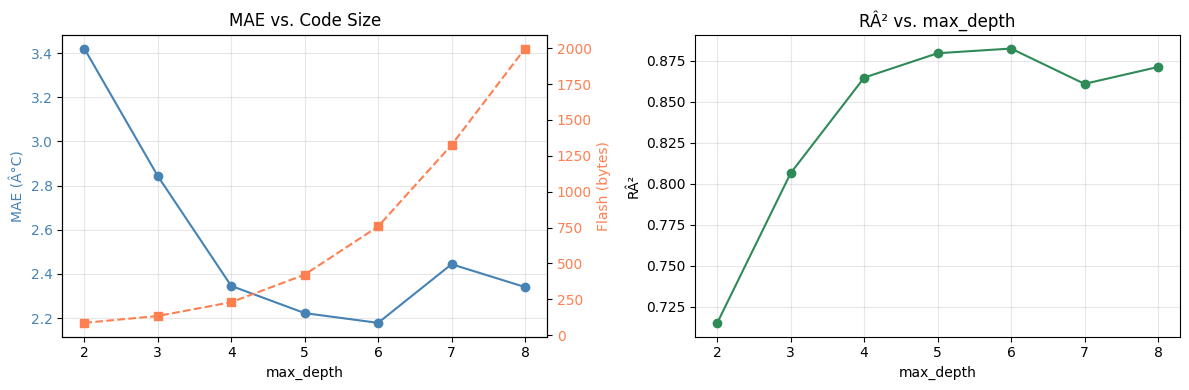

The elbow at depth=4-5 is usually the best operating point.


In [5]:
depths = [2, 3, 4, 5, 6, 7, 8]
mae_vals, r2_vals, size_vals = [], [], []

for d in depths:
    m = DecisionTreeRegressor(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    mae_vals.append(mean_absolute_error(y_test, m.predict(X_test)))
    r2_vals.append(r2_score(y_test, m.predict(X_test)))
    cfg  = ConversionConfig(max_depth=d)
    conv = Converter(cfg)
    conv.convert(model=m, X_train=X_train, feature_names=feature_names)
    size_vals.append(conv.get_metrics()["size_estimate"]["flash_bytes"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(depths, mae_vals, "o-", color="steelblue", label="MAE (°C)")
ax1.set_xlabel("max_depth")
ax1.set_ylabel("MAE (°C)", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1b = ax1.twinx()
ax1b.plot(depths, size_vals, "s--", color="coral", label="Flash (bytes)")
ax1b.set_ylabel("Flash (bytes)", color="coral")
ax1b.tick_params(axis="y", labelcolor="coral")
ax1.set_title("MAE vs. Code Size")
ax1.grid(True, alpha=0.3)

ax2.plot(depths, r2_vals, "o-", color="seagreen")
ax2.set_xlabel("max_depth")
ax2.set_ylabel("R²")
ax2.set_title("R² vs. max_depth")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("depth_tradeoff.png", dpi=120, bbox_inches="tight")
plt.show()
print("The elbow at depth=4-5 is usually the best operating point.")

## 4. Fixed-point arithmetic — for MCUs without FPU


Devices like **Arduino Uno (ATmega328P)** or **STM32F0** lack a hardware floating-point unit (FPU). Floating-point operations are emulated in software, which is slow and wastes flash. BlackBox2C can emit fixed-point arithmetic instead.

In [6]:
model_fp = DecisionTreeRegressor(max_depth=4, random_state=42)
model_fp.fit(X_train, y_train)

# Floating-point version
cfg_float = ConversionConfig(function_name="predict_temp_float", max_depth=4, use_fixed_point=False)
code_float = convert(model_fp, X_train, feature_names=feature_names, config=cfg_float)

# Fixed-point version (16-bit, Q8.8)
cfg_fixed = ConversionConfig(function_name="predict_temp_fixed", max_depth=4, use_fixed_point=True, precision=16)
code_fixed = convert(model_fp, X_train, feature_names=feature_names, config=cfg_fixed)

print(f"Float version:  {len(code_float):>6} bytes")
print(f"Fixed-pt version: {len(code_fixed):>6} bytes")
print()
print("--- Fixed-point output ---")
print(code_fixed)


Starting conversion for model: DecisionTreeRegressor
  Task: Regression, Features: 3, Max depth: 4

[1/4] Extracting surrogate decision tree...
  Model is already a decision tree, using directly.

[2/4] Optimizing decision rules...
  Nodes: 31, Leaves: 24, Depth: 4

[3/4] Generating C code...

[4/4] Estimating code size...
  Estimated FLASH: 230 bytes, RAM: 32 bytes

[OK] Conversion complete!

Starting conversion for model: DecisionTreeRegressor
  Task: Regression, Features: 3, Max depth: 4

[1/4] Extracting surrogate decision tree...
  Model is already a decision tree, using directly.

[2/4] Optimizing decision rules...
  Nodes: 31, Leaves: 28, Depth: 4

[3/4] Generating C code...

[4/4] Estimating code size...
  Estimated FLASH: 198 bytes, RAM: 32 bytes

[OK] Conversion complete!
Float version:    1347 bytes
Fixed-pt version:    862 bytes

--- Fixed-point output ---
/*
 * Auto-generated C code by BlackBox2C
 *
 * Model Information:
 *   - Input features: 3
 *   *   - Task: Regressio

### Fixed-point in an Arduino sketch

```cpp
#include "temperature_fixed.c"

void loop() {
    // Scale inputs to Q8.8 fixed-point (multiply by 256)
    int32_t features[3];
    features[0] = (int32_t)(getHour()     * 256);
    features[1] = (int32_t)(getHumidity() * 256);
    features[2] = (int32_t)(getPressure() * 256);

    int32_t result = predict_temp_fixed(features);
    float temp_c   = result / 256.0f;  // Convert back
    Serial.println(temp_c);
}
```

> **When to use fixed-point?**  
> Only on devices without an FPU. On modern ARM Cortex-M4/M7 or ESP32, floating-point is hardware-accelerated — keep it simple and use floats.